# 1. Exploratory Data Analysis & Preprocessing

## Loading Dataset

In [ ]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 19.3 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("MAO_B_analysis_raw.csv", sep=";")
df_work = df.copy()
df_work.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL4083836,NaN,NaN,380.53,1.0,5.03,TM-31,CCN(CCCCCCOc1ccc2c(c1)NC(=O)CC2)Cc1ccccc1,IC50,'=',...,CHEMBL4033676,1,Scientific Literature,Bioorg Med Chem,2017,NaN,NaN,NaN,NaN,1.70
1,CHEMBL92401,IPRONIAZID,2.0,179.22,0.0,0.72,Iproniazid,CC(C)NNC(=O)c1ccncc1,IC50,'=',...,CHEMBL4033676,1,Scientific Literature,Bioorg Med Chem,2017,NaN,NaN,NaN,NaN,1.78
2,CHEMBL5758556,NaN,NaN,270.42,0.0,3.01,BDBM256497,c1cc([C@H]2C[C@@H]2NCC2CCNCC2)ccc1C1CC1,IC50,'=',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,3790.00
3,CHEMBL5936973,NaN,NaN,296.42,0.0,2.52,BDBM256499,c1cc(-c2ccc([C@H]3C[C@@H]3NCC3CCNCC3)cc2)[nH]n1,IC50,'>',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,100000.00
4,CHEMBL5829534,NaN,NaN,223.35,0.0,1.34,BDBM256473,c1ncc([C@H]2C[C@@H]2NC2CCNCC2)s1,IC50,'>',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,100000.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8656 entries, 0 to 8655
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          8656 non-null   object 
 1   Molecule Name               757 non-null    object 
 2   Molecule Max Phase          641 non-null    float64
 3   Molecular Weight            8649 non-null   float64
 4   #RO5 Violations             8600 non-null   float64
 5   AlogP                       8600 non-null   float64
 6   Compound Key                8656 non-null   object 
 7   Smiles                      8649 non-null   object 
 8   Standard Type               8656 non-null   object 
 9   Standard Relation           8426 non-null   object 
 10  Standard Value              8426 non-null   float64
 11  Standard Units              8432 non-null   object 
 12  pChEMBL Value               5560 non-null   float64
 13  Data Validity Comment       402 n

In [ ]:
df.shape

(8656, 48)

## 1.1 Target analysis + Problem definition

The goal of this project is to build a QSAR model that predicts the biological activity (pChEMBL Value) of small molecules against the MAO-B target based on their molecular structure.

**Target**:
*pChEMBL Value*. It is a continuous numerical variable that represents the logarithmic biological activity of compounds against the MAO-B target. Higher values correspond to stronger inhibitory activity.

Since the target variable is continuous, the problem is formulated as a regression task.
Regression is appropriate because we aim to predict exact activity values rather than assign compounds to discrete activity classes, which is more informative for QSAR modelling and compound ranking and predictions can be used to rank and compare potential inhibitors.

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (8656, 48)


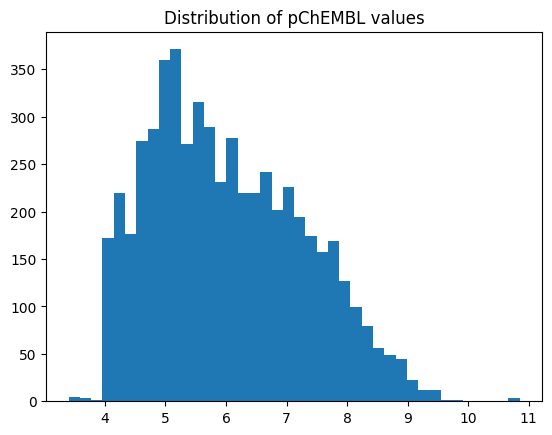

In [ ]:
plt.hist(df['pChEMBL Value'].dropna(), bins=40)
plt.title("Distribution of pChEMBL values")
plt.show()

## 1.2 Feature Analysis

Molecular Weight describes the size of the molecule, AlogP represents lipophilicity, while #RO5 Violations indicates the number of Lipinski’s rule-of-five violations.

Although #RO5 Violations is stored as an integer, it is treated as an ordinal categorical feature rather than a continuous numerical variable.

In [ ]:
num_continuous = ['Molecular Weight', 'AlogP']
num_ordinal = ['#RO5 Violations']

In [ ]:
df[num_continuous].describe()

,Molecular Weight,AlogP
count,8649.000000,8600.000000
mean,339.440106,3.378281
std,132.067403,1.314898
min,70.090000,-5.230000
25%,280.330000,2.550000
50%,329.440000,3.350000
75%,386.500000,4.130000
max,3762.380000,11.140000


In [ ]:
df[['Molecular Weight', '#RO5 Violations', 'AlogP']].isna().sum()

,0
Molecular Weight,7
#RO5 Violations,56
AlogP,56


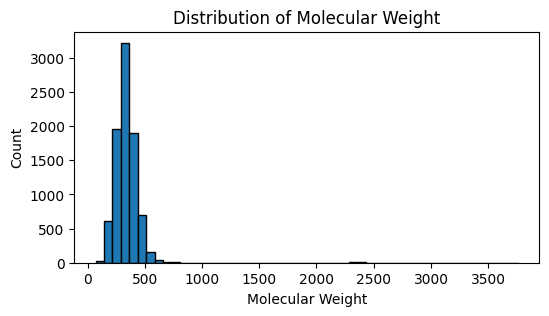

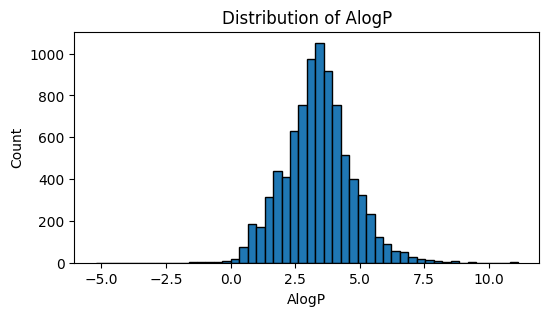

In [ ]:
for col in num_continuous:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=50, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

RO5 Violations was treated as an ordinal categorical feature because it has few discrete values, and its format was fixed (tuple to numeric) so it can be correctly analyzed and used by models. This ensures proper feature analysis and avoids plotting or modeling errors.

In [ ]:
print(df[num_ordinal].value_counts().sort_index().index)
print(type(df[num_ordinal].value_counts().sort_index().index[0]))

def fix_ro5(x):
    if pd.isna(x):
        return np.nan
    elif isinstance(x, tuple):
        return int(x[0])
    else:
        return int(x)

df['#RO5 Violations'] = df['#RO5 Violations'].apply(fix_ro5)

print("Corrected type: ", df['#RO5 Violations'].dtype)
print("Количество NaN:", df['#RO5 Violations'].isna().sum())

MultiIndex([(0.0,),
            (1.0,),
            (2.0,),
            (3.0,)],
           names=['#RO5 Violations'])
<class 'tuple'>
Corrected type:  float64
Количество NaN: 56


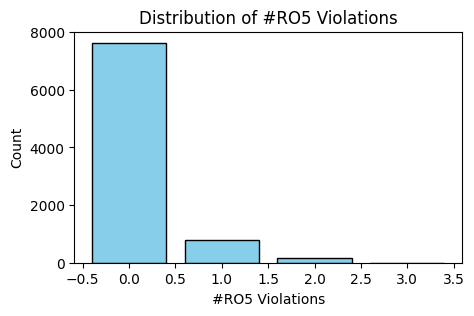

In [ ]:
counts = df['#RO5 Violations'].value_counts(dropna=False).sort_index()

plt.figure(figsize=(5,3))
plt.bar(counts.index, counts.values, edgecolor='black', color='skyblue')
plt.xlabel('#RO5 Violations')
plt.ylabel('Count')
plt.title('Distribution of #RO5 Violations')
plt.show()

Descriptive statistics show that these features have reasonable ranges and no extreme or suspicious values. While none of the descriptors appear redundant, their individual correlation with the target is expected to be limited, so they are mainly used to complement structural information from molecular fingerprints.

## 1.3 Correlations & Main Ideas about Dataset

The correlation matrix shows only weak linear correlations between the molecular descriptors and the target pChEMBL Value. This indicates that biological activity is not well explained by simple physicochemical properties alone.

These results suggest that nonlinear relationships and detailed structural information are important, motivating the use of molecular fingerprints and nonlinear machine learning models for QSAR modelling.

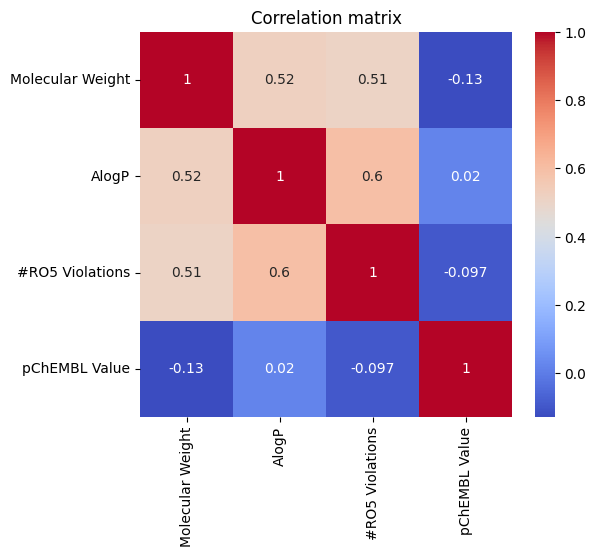

In [ ]:
corr_cols = [
    "Molecular Weight",
    "AlogP",
    "#RO5 Violations",
    "pChEMBL Value"
]

corr = df_work[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

Activity depends on more complex structural features. Compounds in later development phases tend to have higher average pChEMBL values, indicating that biological activity is an important factor in compound progression.

Based on these observations, the main hypothesis is that accurate prediction of MAO-B inhibition requires nonlinear models and structure-based features such as molecular fingerprints rather than relying solely on basic descriptors.

## 1.4 Preprocessing: Anomalies, Missing Values, Categories Analysis, Task-related preprocessing (Regression)

All rows without Standard Value were removed because pChEMBL cannot be calculated without it. Ensures that only valid measurements are used for regression.

In [ ]:
df_proc = df.copy()

print("NaN in Standard Value before:", df_proc['Standard Value'].isna().sum())
df_proc = df_proc[df_proc['Standard Value'].notna()].copy()
print("After:", df_proc['Standard Value'].isna().sum())
print("Dataset shape:", df_proc.shape)

NaN in Standard Value before: 230
After: 0
Dataset shape: (8426, 48)


Removed extra quotes and spaces from the Standard Relation column. This allows correct interpretation of equality (=) and inequality (>) symbols during pChEMBL calculation.

In [ ]:
print(df_proc['Standard Relation'].unique())
df_proc['Standard Relation'] = df_proc['Standard Relation'].str.strip().str.replace("'", "")
print(df_proc['Standard Relation'].unique())

["'='" "'>'" "'<'" "'>='"]
['=' '>' '<' '>=']



IC50 values with = were converted to pChEMBL using the formula: -log10(IC50 * 1e-9).

For very weak molecules (>), the minimum observed pChEMBL among = measurements was assigned. Other undefined cases (<, >=) were left as NaN.

In [ ]:
known = df_proc[df_proc['Standard Relation'] == '=']['Standard Value'].dropna()
min_pchembl = (-np.log10(known * 1e-9)).min()

def pchembl_with_bounds(row):
    if row['Standard Relation'] == '=' and pd.notna(row['Standard Value']):
        return -np.log10(row['Standard Value'] * 1e-9)
    elif row['Standard Relation'] == '>' and pd.notna(row['Standard Value']):
        return min_pchembl
    else:
        return np.nan

df_proc['pChEMBL Value'] = df_proc.apply(pchembl_with_bounds, axis=1)
print("Number of NaN in pChEMBL Value:", df_proc['pChEMBL Value'].isna().sum())


Number of NaN in pChEMBL Value: 79


Any rows where pChEMBL could not be calculated were dropped.
This ensures that the target variable is fully defined for regression.

Duplicate molecules will be removed by grouping by SMILES.

pChEMBL values were averaged for duplicates. Descriptors (Molecular Weight, AlogP, #RO5 Violations) were taken from the first non-missing value.

This ensures each molecule appears only once in the dataset. Checked the shape of the dataset and statistics of pChEMBL after preprocessing.

In [ ]:
def first_not_null(series):
    return series.dropna().iloc[0] if not series.dropna().empty else np.nan

df_proc = df_proc.groupby('Smiles').agg({
    'pChEMBL Value': 'mean',
    'Molecular Weight': first_not_null,
    'AlogP': first_not_null,
    '#RO5 Violations': first_not_null,
}).reset_index()

print(df_proc[['pChEMBL Value', 'Molecular Weight', 'AlogP', '#RO5 Violations']].isna().sum())
print("After deleting duplicates:", df_proc.shape)

pChEMBL Value       74
Molecular Weight     0
AlogP               25
#RO5 Violations     25
dtype: int64
After deleting duplicates: (5983, 5)


In [ ]:
df_proc = df_proc.dropna(subset=['pChEMBL Value','Molecular Weight', 'AlogP', '#RO5 Violations'])
print(df_proc[['pChEMBL Value', 'Molecular Weight', 'AlogP', '#RO5 Violations']].isna().sum())

pChEMBL Value       0
Molecular Weight    0
AlogP               0
#RO5 Violations     0
dtype: int64


The dataset is now clean, numeric features are ready, and all SMILES are unique.

## 1.5 Feature Generation

RDKit descriptors were used to calculate more than 200 standard physicochemical properties for each molecule. These descriptors describe the global characteristics of molecules, such as size, polarity, and overall structural complexity, providing a general physicochemical representation of each compound.

Morgan fingerprints were generated by decomposing each molecule into local atomic environments and encoding their presence into a 1024-bit binary vector. This representation captures detailed molecular topology and the presence of specific chemical substructures, focusing on the internal structural patterns rather than global properties.

https://drzinph.com/rdkit_2d-descriptors-in-python-part-4/

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.decomposition import TruncatedSVD

# 1. Descriptors
desc_names = [d[0] for d in Descriptors._descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)
mols = [Chem.MolFromSmiles(smi) for smi in df_proc['Smiles']]
X_rdkit_all = []

for m in mols:
    if m is None:
        X_rdkit_all.append([np.nan] * len(desc_names))
    else:
        X_rdkit_all.append(calculator.CalcDescriptors(m))

df_rdkit = pd.DataFrame(X_rdkit_all, columns=desc_names)

# 2. Morgan Fingerprints
radius = 2
fpSize = 1024
gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)

X_fp = []
for m in mols:
    if m is None:
        X_fp.append(np.zeros(fpSize))
    else:
        fp = gen.GetFingerprint(m)
        arr = np.zeros((fpSize,), dtype=int)
        ConvertToNumpyArray(fp, arr)
        X_fp.append(arr)
X_fp = np.array(X_fp)

# 3. SVD
svd = TruncatedSVD(n_components=50, random_state=42)
X_fp_reduced = svd.fit_transform(X_fp)
df_fp_reduced = pd.DataFrame(X_fp_reduced, columns=[f'svd_fp_{i}' for i in range(50)])

df_full = pd.concat([df_proc.reset_index(drop=True),
                     df_rdkit.reset_index(drop=True),
                     df_fp_reduced.reset_index(drop=True)], axis=1)

df_full.head()

,Smiles,pChEMBL Value,Molecular Weight,AlogP,#RO5 Violations,Molecular Weight_is_outlier,AlogP_is_outlier,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,svd_fp_40,svd_fp_41,svd_fp_42,svd_fp_43,svd_fp_44,svd_fp_45,svd_fp_46,svd_fp_47,svd_fp_48,svd_fp_49
0,Br.CCOC(=O)C(C(=O)N/N=C/c1ccc([N+](=O)[O-])cc1...,7.698970,488.32,2.29,0.0,0,0,12.693838,12.693838,0.000000,...,-0.829413,-0.694527,-0.293248,-1.221602,0.004044,-0.971967,-0.325949,0.237666,1.306564,0.264758
1,Br.CCOc1ccc(-c2n[nH]cc2C2=NCCN2)cc1,1.230000,337.22,1.83,0.0,0,0,5.443938,5.443938,0.000000,...,0.202748,-0.312357,0.566727,-0.000873,-0.448249,0.027202,0.722492,0.337339,0.352410,-0.200908
2,Br.COc1ccc(C2=NCCN2)cc1Cn1ccnc1C,1.230000,351.25,1.60,0.0,0,0,5.457596,5.457596,0.000000,...,-0.059672,0.622384,0.310246,-0.135326,-0.111411,0.109594,0.777772,0.549119,-0.197255,-0.690708
3,Br.c1ccc(-n2cc(C3=NCCN3)c(-c3cccs3)n2)cc1,4.735182,375.30,2.95,0.0,0,0,4.773750,4.773750,0.000000,...,0.370238,0.504676,0.528244,-0.107077,-0.071850,0.570685,0.348111,0.098175,0.270774,-0.516726
4,Brc1ccc(-c2cc3ccccc3o2)cc1,6.468521,273.13,4.86,0.0,0,0,5.778639,5.778639,0.910833,...,0.262604,-0.090144,-0.610670,-0.014150,0.486537,-0.063679,-0.341234,-0.213476,0.084889,-0.230301


To address the high dimensionality and sparsity of the fingerprint matrix, Truncated SVD was applied to reduce the 1024 fingerprint features to 50 latent components.

### Feature analysis and cleaning after generation

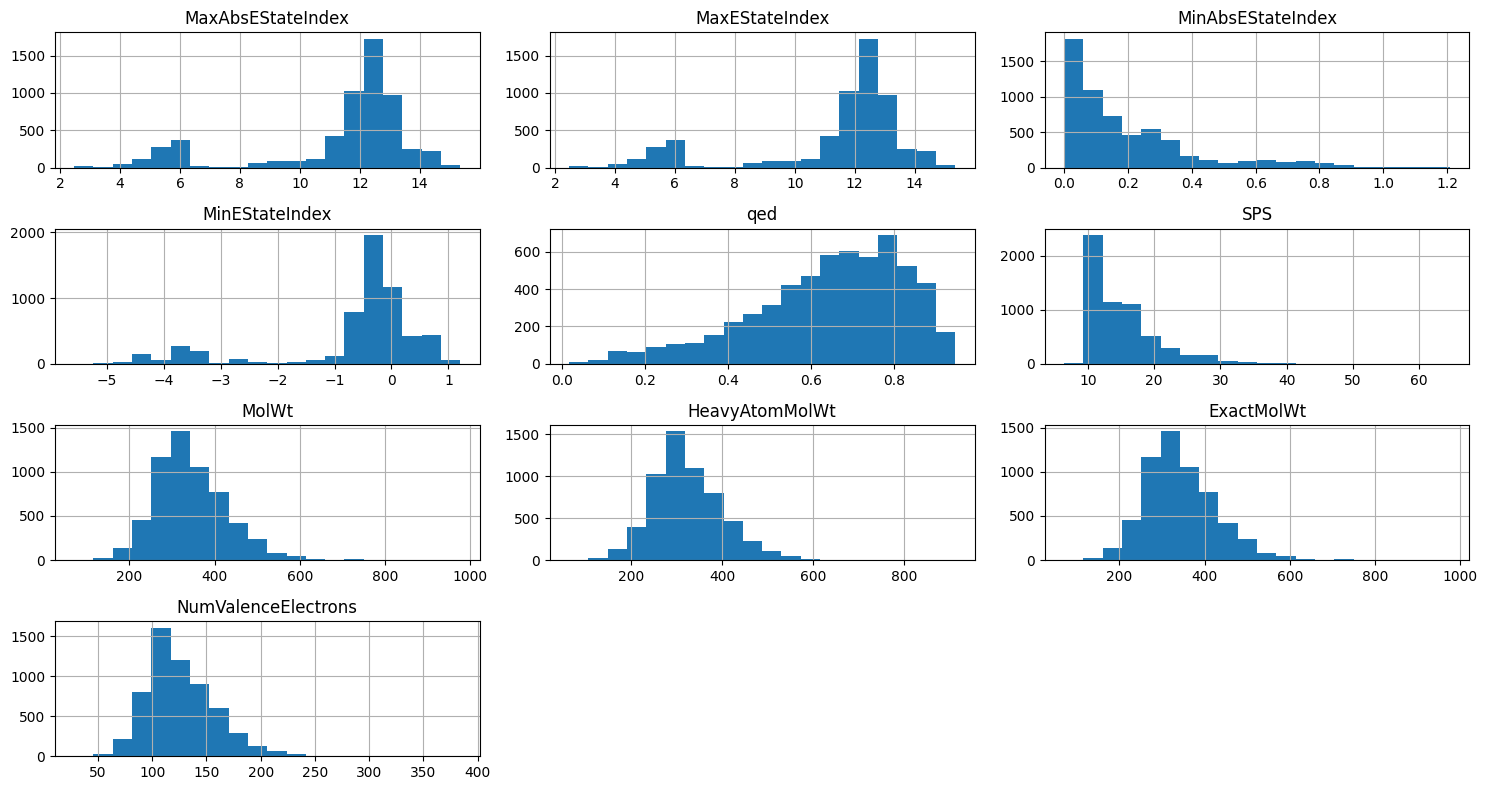

In [ ]:
num_cols = df_rdkit.columns[:10]
df_full[num_cols].hist(bins=20, figsize=(15,8))
plt.tight_layout()
plt.show()

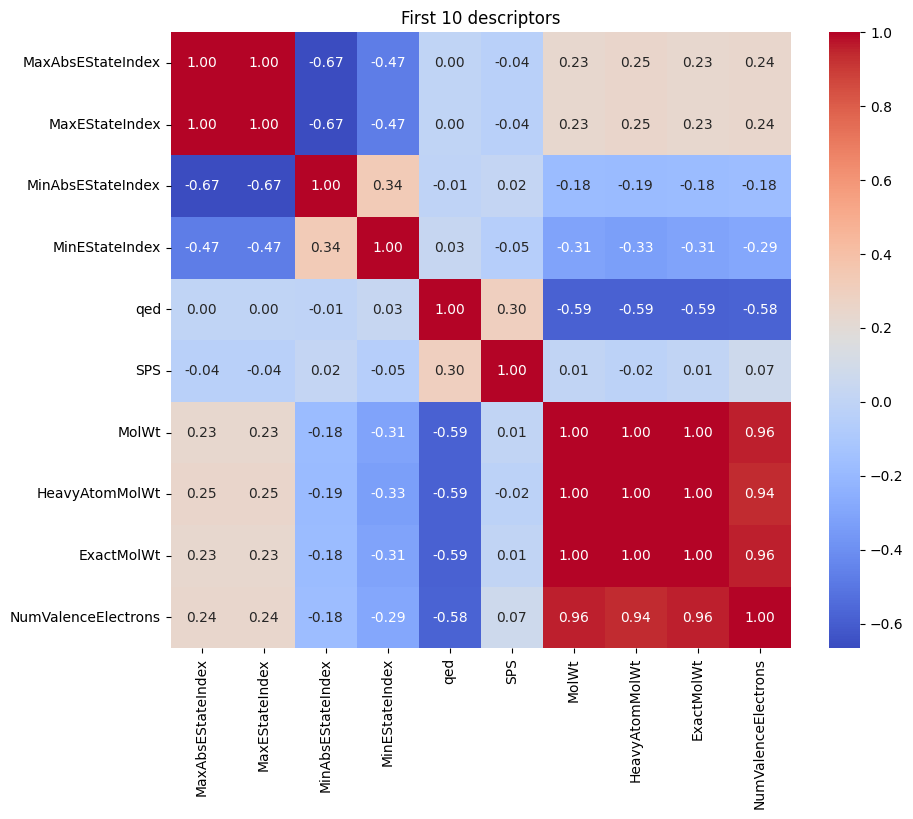

In [ ]:
corr_matrix = df_full[num_cols].corr()
plt.figure(figsize=(10,8))
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("First 10 descriptors")
plt.show()

In [ ]:
numeric_df = df_full.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr().abs()
threshold = 0.90

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    column for column in upper.columns
    if any(upper[column] > threshold)
]

to_drop = list(set(to_drop_corr))
to_drop = [col for col in to_drop if col in df_full.columns]

print(f"Delete {len(to_drop)} features from {numeric_df.shape[1]} numerics.")
print("Correlation-based removed:", len(to_drop_corr))

df_full_clean = df_full.drop(columns=to_drop)

Delete 46 features from 273 numerics.
Manually removed: ['Molecular Weight_is_outlier', 'AlogP_is_outlier']
Correlation-based removed: 44


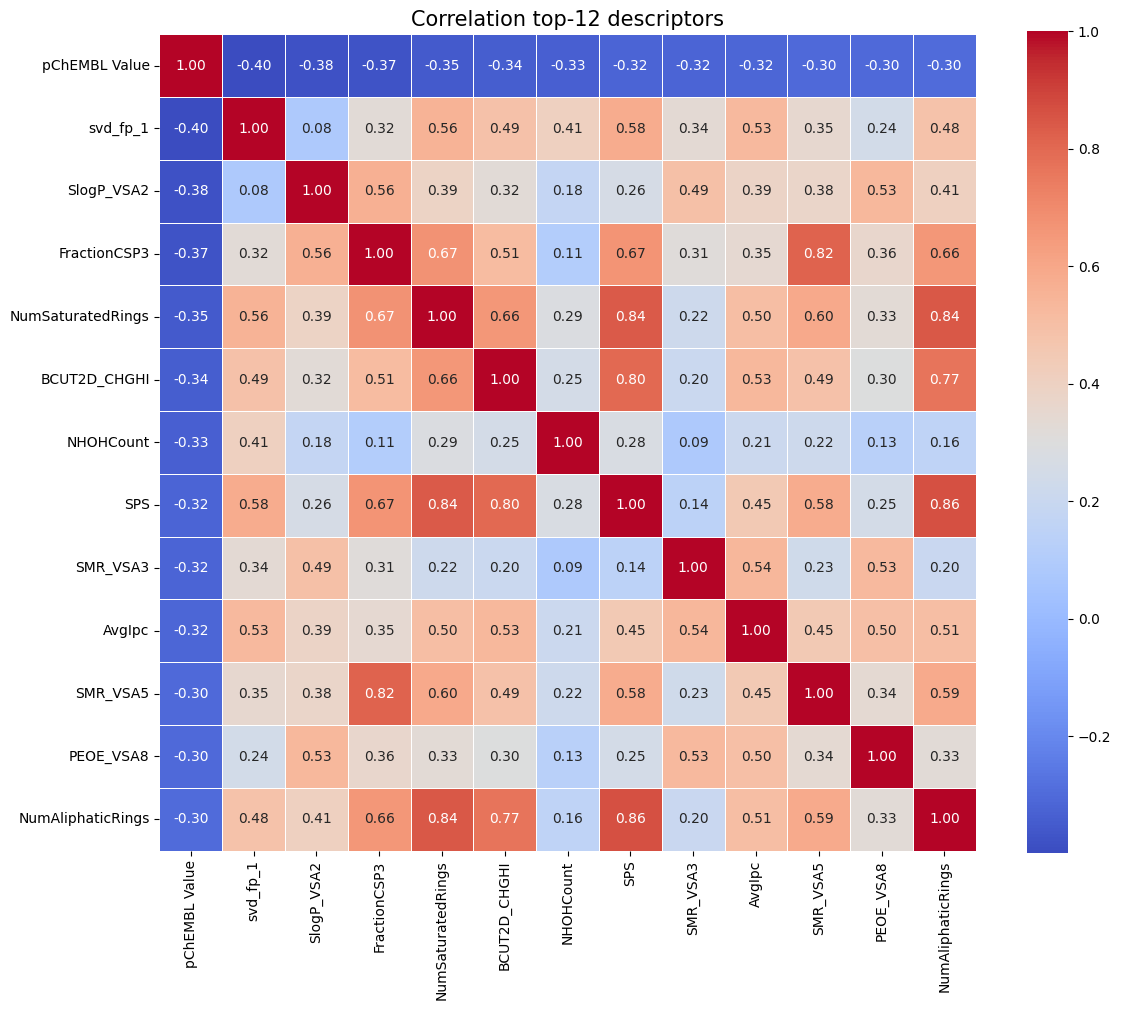

In [ ]:
numeric_final = df_full_clean.select_dtypes(include=[np.number])
correlations_with_target = numeric_final.corr()['pChEMBL Value'].abs().sort_values(ascending=False)

top_features = correlations_with_target.index[:13]
final_corr_matrix = numeric_final[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(final_corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            square=True)

plt.title("Correlation top-12 descriptors", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
df_full_clean.head()

,Smiles,pChEMBL Value,Molecular Weight,AlogP,#RO5 Violations,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,svd_fp_40,svd_fp_41,svd_fp_42,svd_fp_43,svd_fp_44,svd_fp_45,svd_fp_46,svd_fp_47,svd_fp_48,svd_fp_49
0,Br.CCOC(=O)C(C(=O)N/N=C/c1ccc([N+](=O)[O-])cc1...,7.698970,488.32,2.29,0.0,12.693838,0.000000,-1.260586,0.137229,11.516129,...,-0.829413,-0.694527,-0.293248,-1.221602,0.004044,-0.971967,-0.325949,0.237666,1.306564,0.264758
1,Br.CCOc1ccc(-c2n[nH]cc2C2=NCCN2)cc1,1.230000,337.22,1.83,0.0,5.443938,0.000000,0.000000,0.900634,13.350000,...,0.202748,-0.312357,0.566727,-0.000873,-0.448249,0.027202,0.722492,0.337339,0.352410,-0.200908
2,Br.COc1ccc(C2=NCCN2)cc1Cn1ccnc1C,1.230000,351.25,1.60,0.0,5.457596,0.000000,0.000000,0.918740,13.333333,...,-0.059672,0.622384,0.310246,-0.135326,-0.111411,0.109594,0.777772,0.549119,-0.197255,-0.690708
3,Br.c1ccc(-n2cc(C3=NCCN3)c(-c3cccs3)n2)cc1,4.735182,375.30,2.95,0.0,4.773750,0.000000,0.000000,0.761197,13.363636,...,0.370238,0.504676,0.528244,-0.107077,-0.071850,0.570685,0.348111,0.098175,0.270774,-0.516726
4,Brc1ccc(-c2cc3ccccc3o2)cc1,6.468521,273.13,4.86,0.0,5.778639,0.910833,0.910833,0.616568,10.812500,...,0.262604,-0.090144,-0.610670,-0.014150,0.486537,-0.063679,-0.341234,-0.213476,0.084889,-0.230301


In [ ]:
df_full_clean.to_csv('maob_qsar_with_descriptors_clean.csv', index=False)

## 1.6 (Basic) Dimensionality Reduction

PCA shows that the molecules form a single dense cloud with a few outliers. The explained variance of the first two components is relatively low. The color distribution of pChEMBL values is highly mixed, indicating that linear combinations of features do not clearly separate active and inactive compounds, suggesting a predominantly non-linear structure–activity relationship.

First two components explain 13.86% variance


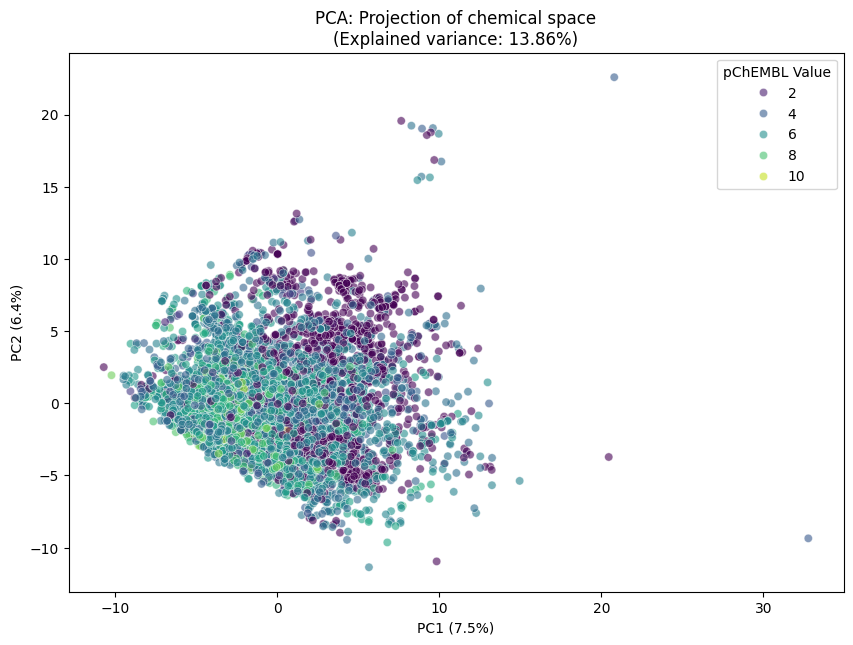

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_all = df_full_clean.select_dtypes(include=[np.number]).drop(columns=['pChEMBL Value'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f"First two components explain {var_exp.sum():.2%} variance")

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df_full_clean['pChEMBL Value'], palette='viridis', alpha=0.6)
plt.title(f"PCA: Projection of chemical space\n(Explained variance: {var_exp.sum():.2%})")
plt.xlabel(f"PC1 ({var_exp[0]:.1%})")
plt.ylabel(f"PC2 ({var_exp[1]:.1%})")
plt.show()

t-SNE reveals well-defined clusters corresponding to groups of structurally similar molecules. Some clusters are enriched with low-activity compounds, while others contain a mixture of activities. The overlap of different colors within the same clusters highlights the presence of "activity cliffs," where small structural changes lead to significant differences in potency. This complexity confirms that the model must learn subtle structural features rather than just general molecular properties.

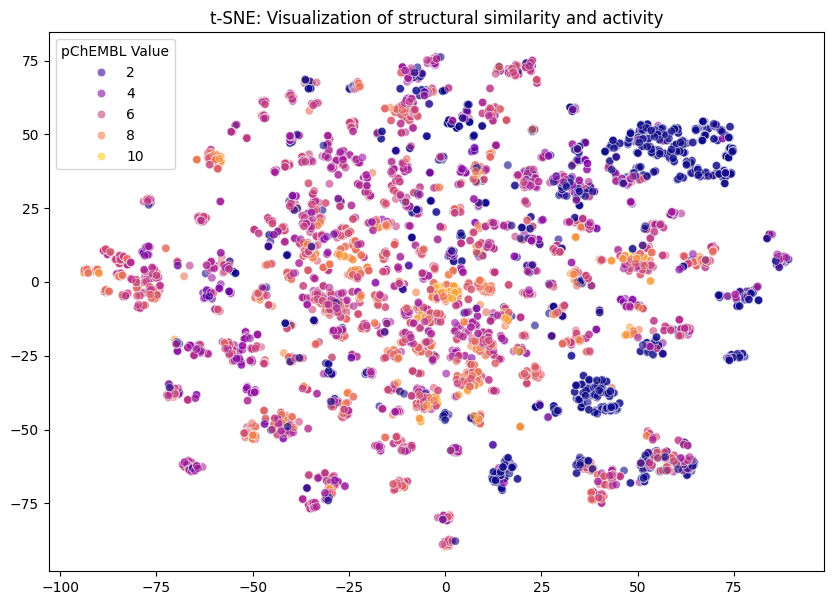

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1],
                hue=df_full_clean['pChEMBL Value'], palette='plasma', alpha=0.6)
plt.title("t-SNE: Visualization of structural similarity and activity")
plt.show()

## 1.7 EDA & Preprocessing Report

before

In [ ]:
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL4083836,NaN,NaN,380.53,1.0,5.03,TM-31,CCN(CCCCCCOc1ccc2c(c1)NC(=O)CC2)Cc1ccccc1,IC50,'=',...,CHEMBL4033676,1,Scientific Literature,Bioorg Med Chem,2017,NaN,NaN,NaN,NaN,1.70
1,CHEMBL92401,IPRONIAZID,2.0,179.22,0.0,0.72,Iproniazid,CC(C)NNC(=O)c1ccncc1,IC50,'=',...,CHEMBL4033676,1,Scientific Literature,Bioorg Med Chem,2017,NaN,NaN,NaN,NaN,1.78
2,CHEMBL5758556,NaN,NaN,270.42,0.0,3.01,BDBM256497,c1cc([C@H]2C[C@@H]2NCC2CCNCC2)ccc1C1CC1,IC50,'=',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,3790.00
3,CHEMBL5936973,NaN,NaN,296.42,0.0,2.52,BDBM256499,c1cc(-c2ccc([C@H]3C[C@@H]3NCC3CCNCC3)cc2)[nH]n1,IC50,'>',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,100000.00
4,CHEMBL5829534,NaN,NaN,223.35,0.0,1.34,BDBM256473,c1ncc([C@H]2C[C@@H]2NC2CCNCC2)s1,IC50,'>',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,100000.00


after

In [ ]:
df_full_clean.head()

,Smiles,pChEMBL Value,Molecular Weight,AlogP,#RO5 Violations,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,svd_fp_40,svd_fp_41,svd_fp_42,svd_fp_43,svd_fp_44,svd_fp_45,svd_fp_46,svd_fp_47,svd_fp_48,svd_fp_49
0,Br.CCOC(=O)C(C(=O)N/N=C/c1ccc([N+](=O)[O-])cc1...,7.698970,488.32,2.29,0.0,12.693838,0.000000,-1.260586,0.137229,11.516129,...,-0.829413,-0.694527,-0.293248,-1.221602,0.004044,-0.971967,-0.325949,0.237666,1.306564,0.264758
1,Br.CCOc1ccc(-c2n[nH]cc2C2=NCCN2)cc1,1.230000,337.22,1.83,0.0,5.443938,0.000000,0.000000,0.900634,13.350000,...,0.202748,-0.312357,0.566727,-0.000873,-0.448249,0.027202,0.722492,0.337339,0.352410,-0.200908
2,Br.COc1ccc(C2=NCCN2)cc1Cn1ccnc1C,1.230000,351.25,1.60,0.0,5.457596,0.000000,0.000000,0.918740,13.333333,...,-0.059672,0.622384,0.310246,-0.135326,-0.111411,0.109594,0.777772,0.549119,-0.197255,-0.690708
3,Br.c1ccc(-n2cc(C3=NCCN3)c(-c3cccs3)n2)cc1,4.735182,375.30,2.95,0.0,4.773750,0.000000,0.000000,0.761197,13.363636,...,0.370238,0.504676,0.528244,-0.107077,-0.071850,0.570685,0.348111,0.098175,0.270774,-0.516726
4,Brc1ccc(-c2cc3ccccc3o2)cc1,6.468521,273.13,4.86,0.0,5.778639,0.910833,0.910833,0.616568,10.812500,...,0.262604,-0.090144,-0.610670,-0.014150,0.486537,-0.063679,-0.341234,-0.213476,0.084889,-0.230301


The data preparation phase involved transforming the raw ChEMBL dataset into a high-quality feature matrix suitable for machine learning. Exploratory analysis showed that biological activity exhibits weak linear correlations with basic molecular properties and is governed by highly non-linear structure–activity relationships.

The feature generation process combined the calculation of 200+ global RDKit physicochemical descriptors and 1024-bit Morgan fingerprints encoding the local topology of molecules. To improve data quality, a filtering step was performed, completely removing highly correlated features that created redundancy. The resulting feature space was balanced by compressing the fingerprints into 50 SVD components.

PCA failed to separate compounds by activity, whereas t-SNE revealed distinct structural clusters with heterogeneous activity levels, indicating the presence of activity cliffs.

The next stage will involve:
*   comparing several baseline regression models
*   hyperparameter optimization
*   model evaluation
*   SHAP analysis